# Introduction to Machine Learning: Deep Learning

**Instructor:** Daniel Acuna, Ph.D.
**Position:** Associate Professor of Computer Science
**Institution:** University of Colorado Boulder

---

Lab 1: Neural Network Foundations and the Mathematics of Learning

---

## Setup (do not edit)

In [66]:
import pathlib
from typing import Tuple, Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Suppress TensorFlow warnings for cleaner output
tf.get_logger().setLevel("ERROR")

RANDOM_STATE: int = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

_DATA_PATH = pathlib.Path("breast_cancer_nn.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "breast_cancer_nn.csv is missing from the lab directory. Please download it or ask the TA "
        "for assistance."
    )

## 1. Load and Explore the Dataset *(10 points)*

Write a function `load_data()` that reads `breast_cancer_nn.csv` into a `pandas.DataFrame`.
Store the shape of the DataFrame in a variable called **`q1_shape`**.

The dataset contains 30 features computed from digitized images of breast mass fine needle
aspirates, plus a `target` column (0 = malignant, 1 = benign).

In [67]:


def load_data() -> pd.DataFrame:
    """Load the Breast Cancer Wisconsin dataset from CSV.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing the 30 features plus the target column.
    """
    # your code here
#     raise NotImplementedError

    return pd.read_csv('breast_cancer_nn.csv')


# Compute the answer required by the autograder
q1_shape: Tuple[int, int] = load_data().shape

In [68]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 1
assert isinstance(q1_shape, tuple), (
    "q1_shape must be a tuple. Use df.shape which returns (rows, cols)."
)
assert len(q1_shape) == 2, (
    "q1_shape should have 2 elements (rows, cols). "
    "Make sure you're using .shape, not .shape[0]."
)
assert q1_shape[0] > 0 and q1_shape[1] > 0, (
    "Shape values must be positive. Is your CSV loading correctly?"
)
print(f"Dataset shape: {q1_shape}")

Dataset shape: (569, 31)


## 2. Prepare Features and Target *(10 points)*

Separate the dataset into:
- **`X`**: A DataFrame containing all feature columns (everything except `target`)
- **`y`**: A Series containing the `target` column

Store the number of features in **`q2_n_features`** (an integer).

In [69]:
df = load_data()

# your code here
# raise NotImplementedError

display(df.head(2))

display(df.describe())

# ND array of features/predictors/dimensions
X = df.drop(columns=['target'])

# get pd.Series/Vector for target
y = df['target']

q2_n_features = len(list(X.columns))
print(q2_n_features)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


30


In [70]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 2
assert isinstance(q2_n_features, (int, np.integer)), (
    "q2_n_features must be an integer. Use X.shape[1] to get the number of columns."
)
assert q2_n_features > 0, (
    "Number of features must be positive. Did you create X correctly?"
)
assert "target" not in X.columns, (
    "The target column 'target' should not be in your feature matrix X. "
    "Use df.drop(columns='target') to remove it."
)
print(f"Number of features: {q2_n_features}")

Number of features: 30


## 3. Train/Validation/Test Split with Scaling *(10 points)*

Neural networks perform better when features are standardized (zero mean, unit variance).

1. Split the data into **training (60%)**, **validation (20%)**, and **test (20%)** sets.
   Use `random_state=RANDOM_STATE`.
2. Fit a `StandardScaler` on the **training data only**, then transform all three sets.

Store the row counts as a tuple **`q3_split_counts = (n_train, n_val, n_test)`**.

**Hint:** First split into train+val (80%) and test (20%), then split train+val into train (75%) and val (25%).

In [85]:
# your code here
# raise NotImplementedError

# split 80/20
# per https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
X_train_60, X_val_20, y_train_60, y_val_20 = train_test_split(X_train_80, y_train_80, test_size=0.2, random_state=RANDOM_STATE)

# TODO maybe: check split ratios manually but this may be redundant to what train_test_split with test_size is doing


scaler = StandardScaler()
scaler.fit(X_train_60)

# fit_transform is fit and transform on training but separated for convenience downstream
# train_scaled = scaler.fit_transform(X_train_60)
# test_scaled = scaler.fit_transform(X_test_20)
# val_scaled = scaler.fit_transform(X_val_20)

train_scaled = scaler.transform(X_train_60)
test_scaled = scaler.transform(X_test_20)
val_scaled = scaler.transform(X_val_20)
X_train_scaled = train_scaled
X_test_scaled = test_scaled



# Store the row counts as a tuple q3_split_counts = (n_train, n_val, n_test).

n_train = len(X_train_60)
n_val = len(X_val_20)
n_test = len(X_test_20)

q3_split_counts = (n_train, n_val, n_test)
print(q3_split_counts)

print(train_scaled[:2])
print(y_train_60[:2])



# BEGIN HIDDEN TESTS
total = n_train + n_val + n_test
print(total)
assert total == 569, "Total samples should equal 569"
assert abs(n_train / total - 0.6) < 0.05, "Train split should be ~60%"
assert abs(n_val / total - 0.2) < 0.05, "Val split should be ~20%"
print(abs(n_val / total - 0.2))
assert abs(n_test / total - 0.2) < 0.05, "Test split should be ~20%"
# Verify scaling was applied
assert np.abs(train_scaled.mean()) < 0.1, "Training data should be centered"
print(np.abs(train_scaled.mean()))
# END HIDDEN TESTS
assert np.abs(X_train_scaled.mean()) < 0.1, "Training data should be centered"
# END HIDDEN TESTS



(364, 91, 114)
[[ 0.16907934 -0.92257199  0.18229876  0.01219874  1.19459896  0.57474906
   0.15827793  0.59429689  1.02377285  0.08901122  0.35881604 -0.87797821
   0.43088926  0.04391966 -0.47371426  0.99934211  0.40341268  0.69278239
   0.41968382  0.38329144  0.03797246 -1.19808602  0.08567859 -0.11480242
  -0.17009415  0.3622977  -0.03623832  0.40169882  0.35644782  0.04419858]
 [ 0.33448729  2.69222159  0.49843323  0.19623375  0.60804416  1.96597432
   2.10453322  1.20909251  1.0655392   1.17897601 -0.47746145  0.02301273
  -0.22763535 -0.35189391 -0.75498183  1.22860268  1.3482247   0.66929184
   0.07620611  0.85325644  0.2823892   2.86029596  0.66154701  0.0786778
   0.43244432  3.39094875  4.37607168  1.85166428  1.79896979  3.05495626]]
89     1
562    0
Name: target, dtype: int64
569
0.04007029876977153
6.018791488810373e-18


In [72]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 3
assert isinstance(q3_split_counts, tuple), (
    "q3_split_counts must be a tuple like (n_train, n_val, n_test)."
)
assert len(q3_split_counts) == 3, "Tuple should have exactly 3 elements."
n_train, n_val, n_test = q3_split_counts
assert all(n > 0 for n in q3_split_counts), (
    "All splits must have positive row counts."
)
assert n_train > n_val and n_train > n_test, (
    "Training set should be the largest. Check your split ratios."
)
print(f"Train/Val/Test split: {n_train} / {n_val} / {n_test}")

Train/Val/Test split: 364 / 91 / 114


## 4. Build a Neural Network Model *(10 points)*

Using Keras, build a neural network with the following architecture:
- **Input shape:** `(n_features,)` where `n_features` is from Question 2
- **Hidden Layer 1:** 16 neurons with ReLU activation
- **Hidden Layer 2:** 8 neurons with ReLU activation
- **Output Layer:** 1 neuron with Sigmoid activation (for binary classification)

Store the model in a variable called **`model`** and the total number of trainable
parameters in **`q4_n_params`** (an integer).

**Hint:** Use `model.count_params()` to get the parameter count.

In [73]:
# your code here
# raise NotImplementedError

# Import the Sequential model and Dense layer
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense

# found a few refs
# https://www.tensorflow.org/tutorials/load_data/pandas_dataframe

# Create a Sequential model
model = Sequential()

# hidden layer 1
model.add(Dense(16, input_shape=(q2_n_features,), activation="relu"))

# hidden layer 2
model.add(Dense(8, activation="relu"))

# output layer
model.add(Dense(1, activation="sigmoid"))


# total number of trainable parameters in q4_n_params (an integer).

# Summarise your model
# shows total params but 
model.summary()

# thought it would output the same as summary but in json but it does not
# display(model.to_json())

# https://www.tensorflow.org/api_docs/python/tf/keras/backend/count_params
# backend.count_params
print(model.count_params())
q4_n_params = model.count_params()



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

641


In [74]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 4
assert isinstance(model, Sequential), (
    "model should be a Keras Sequential model. "
    "Did you use Sequential([...])?"
)
assert isinstance(q4_n_params, (int, np.integer)), (
    "q4_n_params must be an integer. Use model.count_params()."
)
assert q4_n_params > 0, (
    "Model should have trainable parameters. Did you add layers?"
)
assert len(model.layers) == 3, (
    "Model should have exactly 3 layers (2 hidden + 1 output). "
    "Check your architecture."
)
print(f"Total trainable parameters: {q4_n_params}")

Total trainable parameters: 641


## 5. Compile and Train the Model *(10 points)*

1. **Compile** the model with:
   - Optimizer: `'adam'`
   - Loss: `'binary_crossentropy'`
   - Metrics: `['accuracy']`

2. **Train** the model for **50 epochs** with `batch_size=32` using the training data
   and validation data. Set `verbose=0` to suppress output.

Store the training history object in **`history`** and the final training accuracy
(last epoch) in **`q5_final_train_acc`** (float, rounded to 3 decimals).

In [75]:
# your code here
# raise NotImplementedError

# ref https://www.tensorflow.org/tutorials/load_data/pandas_dataframe

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# ref https://keras.io/api/models/model_training_apis/#fit-method
# "A History object. Its History.history attribute is a record of training loss values and 
# metrics values at successive epochs, as well as validation loss values and 
# validation metrics values (if applicable)."
max_epochs = 50
last_epoch = max_epochs-1
history = model.fit(
#     X_train_60, y_train_60, 
    train_scaled, y_train_60,
    epochs=max_epochs, 
    batch_size=32, 
    verbose=0,
    validation_data=(val_scaled, y_val_20)
)

print(history.params)


# final training accuracy (last epoch) in q5_final_train_acc (float, rounded to 3 decimals).
# ref https://apxml.com/courses/deep-learning-fundamentals-keras/chapter-3-training-deep-neural-networks/validation-data-monitoring
# history.history has the metrics. Could not find this obvious in the keras or tensorflow docs so found it in a
# random article online unfortunately.
# got intitial: "AssertionError: History should contain 'val_accuracy'. Did you pass validation_data to fit()?"
print(history.history.keys())
print(history.history)
print(len(history.history.get('accuracy')))
print(history.history.get('accuracy')[last_epoch])

q5_final_train_acc = float(round(history.history.get('accuracy')[last_epoch], 3))
print(q5_final_train_acc)

{'verbose': 0, 'epochs': 50, 'steps': 12}
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
{'accuracy': [0.7170329689979553, 0.7774725556373596, 0.8296703100204468, 0.8653846383094788, 0.901098906993866, 0.9093406796455383, 0.9230769276618958, 0.9313187003135681, 0.942307710647583, 0.9478021860122681, 0.9560439586639404, 0.9560439586639404, 0.9615384340286255, 0.9670329689979553, 0.9670329689979553, 0.9697802066802979, 0.9725274443626404, 0.9725274443626404, 0.9725274443626404, 0.9835164546966553, 0.9807692170143127, 0.9862637519836426, 0.9862637519836426, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9890109896659851, 0.9917582273483276, 0.9917582273483276, 0.9917582273483276, 0.9917582273483276, 0.9917582273483276, 0.9917582273483276, 0.9917582273483276, 0.9917582273483276, 0.9917

In [76]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 5
assert hasattr(history, 'history'), (
    "history should be a Keras History object. Did you call model.fit()?"
)
assert 'accuracy' in history.history, (
    "History should contain 'accuracy'. Did you include metrics=['accuracy'] in compile?"
)
assert 'val_accuracy' in history.history, (
    "History should contain 'val_accuracy'. Did you pass validation_data to fit()?"
)
assert isinstance(q5_final_train_acc, float), (
    "q5_final_train_acc must be a float."
)
assert 0 <= q5_final_train_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
print(f"Final training accuracy: {q5_final_train_acc:.3f}")

Final training accuracy: 0.995


## 6. Plot Training Curves *(10 points)*

Create a figure with **two subplots** side by side:
1. **Left subplot:** Training and validation **loss** over epochs
2. **Right subplot:** Training and validation **accuracy** over epochs

Both plots should include:
- X-axis label: "Epoch"
- Y-axis labels: "Loss" and "Accuracy" respectively
- Legend showing "Train" and "Validation"

Store the matplotlib figure object in **`q6_fig`**.

**Note:** Looking at these curves helps identify overfitting (when validation loss
increases while training loss continues to decrease).

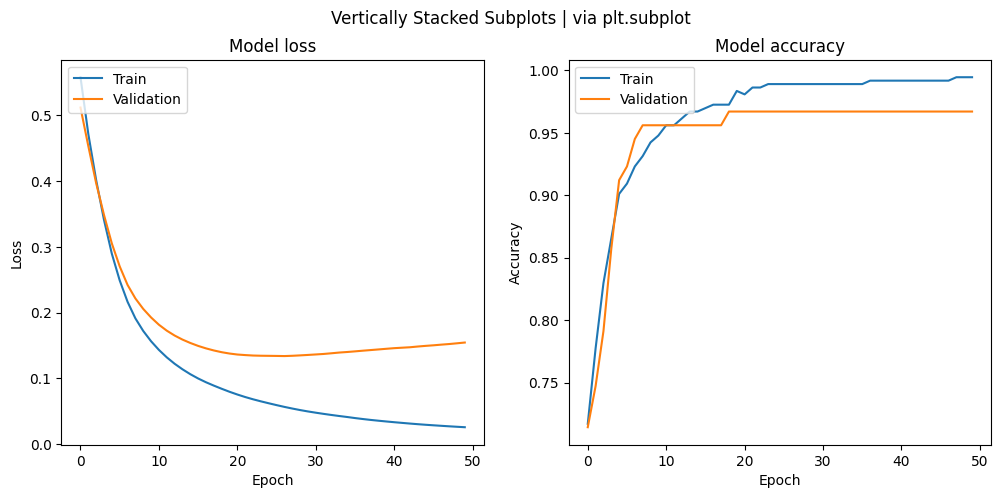

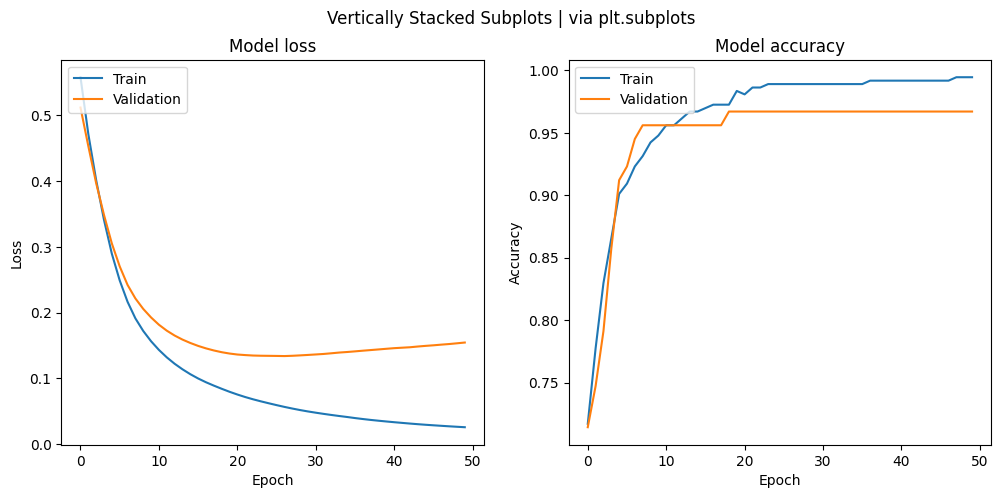

In [77]:
# your code here
# raise NotImplementedError

# ref https://machinelearningmastery.com/display-deep-learning-model-training-history-in-keras/
# as it had a simple example to follow


# prep

# history.history.keys: ['accuracy', 'loss', 'val_accuracy', 'val_loss']
accuracy = history.history.get('accuracy')
loss = history.history.get('loss')
val_accuracy = history.history.get('val_accuracy')
val_loss = history.history.get('val_loss')


# figure via subplot()

# uses https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplot.html#matplotlib.pyplot.subplot
# which is an alternative to 
# https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.subplots.html#matplotlib.figure.Figure.subplots
# and does not need e.g. fig, (ax1, ax2) = plt.subplots(1, 2) but plt.subplot(1, 2, 1) where arg 3 is the index
# and sets the order of the plots
# ref https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html

# fig 1
plt.figure(num=1, figsize=(12, 5))

# Left subplot: Training and validation loss over epochs

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Right subplot: Training and validation accuracy over epochs

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.suptitle('Vertically Stacked Subplots | via plt.subplot')

plt.show()  # <-- Add this to display the first figure

# figure via subplot() END



# figure via subplots()

# via
# https://matplotlib.org/stable/api/_as_gen/matplotlib.figure.Figure.subplots.html#matplotlib.figure.Figure.subplots
# ref https://matplotlib.org/stable/gallery/scales/asinh_demo.html

# fig 2
fig = plt.figure(2, figsize=(12, 5))
ax1, ax2 = fig.subplots(1, 2)
# or just one liner but i could not confirm kwargs to figure in docs but does work??
# prefer the above as it splits it better.
# fig, (ax1, ax2) = plt.subplots(1, 2, num=2, figsize=(12, 5))
    
    
# Left subplot: Training and validation loss over epochs
    
# Plot training & validation loss values
# ax1.subplot(1, 2, 2)
ax1.plot(loss)
ax1.plot(val_loss)
ax1.set_title('Model loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Validation'], loc='upper left')

    
# Right subplot: Training and validation accuracy over epochs

# plt.subplot(1, 2, 1)
ax2.plot(accuracy)
ax2.plot(val_accuracy)
ax2.set_title('Model accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Validation'], loc='upper left')

# Add a title to the entire figure
fig.suptitle('Vertically Stacked Subplots | via plt.subplots')

# Adjust layout
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the figure
plt.show()

# figure via subplots() END


# store 
q6_fig = fig


In [78]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 6
assert isinstance(q6_fig, plt.Figure), (
    "q6_fig must be a matplotlib Figure object. "
    "Use fig, axes = plt.subplots(...) and store fig in q6_fig."
)
assert len(q6_fig.axes) == 2, (
    "Figure should have exactly 2 subplots (loss and accuracy)."
)
print("Training curves plotted successfully!")

Training curves plotted successfully!


## 7. Evaluate on Test Set *(10 points)*

Evaluate the trained model on the **test set** (using the scaled test features).

Store the results as a tuple **`q7_test_metrics = (test_loss, test_accuracy)`**
with both values rounded to **3 decimals**.

In [79]:
# your code here
# raise NotImplementedError


# refs 
# https://www.tensorflow.org/guide/core/quickstart_core#train_and_evaluate_your_model
# https://www.tensorflow.org/guide/keras/sequential_model#what_to_do_once_you_have_a_model
# https://medium.com/swlh/custom-loss-and-custom-metrics-using-keras-sequential-model-api-d5bcd3a4ff28

# evaluate(
#     x=None,
#     y=None,
#     batch_size=None,
#     verbose='auto',
#     sample_weight=None,
#     steps=None,
#     callbacks=None,
#     return_dict=False,
#     **kwargs
# )

# loss, acc, acc_spa = model.evaluate(test_scaled, y_test_20, verbose=1)
# print(loss, acc, acc_spa)
eval_metrics = model.evaluate(test_scaled, y_test_20, verbose=1, return_dict=True)
print(eval_metrics)

# tuple q7_test_metrics = (test_loss, test_accuracy) with both values rounded to 3 decimals.
test_loss = round(eval_metrics.get('loss'),3)
test_accuracy = round(eval_metrics.get('accuracy'),3)
q7_test_metrics = (test_loss, test_accuracy)
print(q7_test_metrics)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9912 - loss: 0.0553
{'accuracy': 0.9912280440330505, 'loss': 0.05529941990971565}
(0.055, 0.991)


In [80]:
# If all tests pass (there might be hidden tests), you will earn 10 points
# Test Cell: Question 7
assert isinstance(q7_test_metrics, tuple), (
    "q7_test_metrics must be a tuple (loss, accuracy)."
)
assert len(q7_test_metrics) == 2, "Tuple should have exactly 2 elements."
test_loss, test_acc = q7_test_metrics
assert isinstance(test_loss, float) and isinstance(test_acc, float), (
    "Both loss and accuracy must be floats."
)
assert test_loss >= 0, "Loss must be non-negative."
assert 0 <= test_acc <= 1, "Accuracy must be between 0 and 1."
print(f"Test Loss: {test_loss:.3f}, Test Accuracy: {test_acc:.3f}")

Test Loss: 0.055, Test Accuracy: 0.991


## 8. Manual Forward Pass Function *(15 points)*

To reinforce your understanding of neural network mathematics, implement a function
that performs a **forward pass manually using NumPy**.

Implement **`manual_forward_pass(X: np.ndarray, weights: List) -> np.ndarray`** that:
1. Takes input data `X` (shape: n_samples × n_features)
2. Takes `weights` from `model.get_weights()` (a list of weight matrices and bias vectors)
3. Applies the forward pass through all layers:
   - For hidden layers: `Z = X @ W + b`, then `A = ReLU(Z)` where ReLU(x) = max(0, x)
   - For output layer: `Z = A @ W + b`, then `output = sigmoid(Z)`
4. Returns the final output probabilities

Store the predictions for the first 5 test samples in **`q8_manual_preds`** (shape: 5×1).

In [84]:
# your code here
# raise NotImplementedError


# AI use:
# this was tough.
# i followed the math dimensional operations per lecture and was able to confirm the parameters 
# manually against the model.summary
# then ran into many issues on
# - once I started to convert to the code
# - and trying to validate between model.predict() (though was optional)
# 
# So my prompts ranged from trying to understand concepts in math to code, to
# noticed nuances with how karas seems to transpose/reshape matrix of input and weights internally
# so after some digging and a few prompts it turns out the order of ops had to change from Wx to xW to work.
# then the list of weights just could not work...could not find in docs nor
# able to just randomly pick the index of model.get_weights() to match the layer.
# i ended up using layer.get_weights() as it gave me the weights and biases per layer as I needed. 
# so...the weights param is useless unfortunately :(. 
# 
# towards the end of crafting the function i got so lost I needed some extra help.
# so i prompt from another 
# "show me "Would you like me to show you how to loop through all layers in a Sequential model to calculate the final prediction from start to finish?""
# and this gave me close to what I used below.
# I kept most of the structure unfurtonately as I could not see another way to do it from karas docs.
# i experimented with some things...
# such as getting the activation name without layer.activation.__name__ but was not successful and docs had not info.
# 
# I tried hard to not use any specific code from AI but honestly I got stuck and karas docs just were lacking.
# I do undertand the flow better now though, and my experiments helped clarify and confirm any code from ai
# so I made sure its valid. 
# The main point of confusion remains the order of weights * inputs and how to use model.get_weights()
# which though make sense I'm not clear why this had to be done this way besides the need to properly
# multiply & sum 2D arrays. 

# confused why I should use model.get_weights() or how??
# it seems to be a list of ndarray and seems to be tied to layers but I don't follow how to understand that yet.
# ref https://keras.io/2/api/models/model_saving_apis/weights_saving_and_loading/#:~:text=set_weights%20method,Copied!
# but its unclear how they are structured and their order per layer
w = model.get_weights()
# print(w)
print(type(w))
print(type(w[0]))
print(w[0].shape)
print(w[1].shape)
print(w[2].shape)
# why 6 and not 1? 
# per https://keras.io/api/layers/base_layer/#getweights-method
# seems to suggest values from layer.weights ??
# expected 1 initially but its per layers so it was 3, so why 6 and not 3?
# my best guess is 3 layers so 3 weights and 3 biases
print(len(w)) 
print(f'weights length: {len(w)}')
# w = np.array(model.get_weights())
# type(w)

print(model.layers)
print(f"layers: {len(model.layers)}")
l0_weights, l0_biases = model.layers[0].get_weights()  
# print(model.layers[0].get_weights())
# 
print('layer 0')
print(type(model.layers[0]))
print(model.layers[0])
print(model.layers[0].activation)
# get name attribute of function
print(model.layers[0].activation.__name__)
print(len(l0_weights))
print(f'l0_weights shape: {l0_weights.shape}')
print(len(l0_biases))
print(l0_biases.shape)


print('new manual_forward_pass............>>>>')

def manual_forward_pass(X: np.ndarray, weights: List) -> np.ndarray:
    """
    This was my final attempt at a manual implementation which now used model.get_weights() as requested.
    
    Notes:
    - this likely will not scale unless the neural network is exactly 3 layers.
    - its not performant at scale due to the 2 loops @ time complexity O^2
    - the use of layers_length+1 for the layer number was arbitrary to match the order the network was 
    initially created. Seems to work for Sequential but thats it. 
    - it has some pros/cons over the initial attempt via manual_forward_pass_001 but output match so thats how 
    I compared them. 
    - If the official docs had more info and examples of this manual approach I would likely been able to 
    find it and apply it. The math to code nuances were discovered in the initial attempt so hence
    why this one is a bit cleaner to read. Mostly due to lack of comments everywhere. 
    """

    # setup
    def relu(x): return tf.keras.activations.relu(x)
    def sigmoid(x): return tf.keras.activations.sigmoid(x)

    # brainstorming
    # took from ai gen via prompt "how to get layer object from model.get_weights() in karas...but if i needed to use model.get_weights() how would i"
    # as this was not at all obvious in the docs, even source code. 
    # The code uses zip() to combine iterables but the layer_names list is particularly odd so did not want to use,
    # though a few lines was cleaner.
    # seems to map but seems odd to use over just layer.get_weights()
    # all_weights = model.get_weights()
    # layer_names = [layer.name for layer in model.layers for _ in layer.weights]

    # # Create a mapping of (Layer Name + Variable Type) to the weight array
    # for name, weight_array in zip(layer_names, all_weights):
    #     print(f"Layer: {name}, Shape: {weight_array.shape}")
    
#   loop model weights to split weights ad biases
    print('model.get_weights.......')
    # [123456]
    layers = {}
    layers_length = 0
    index_reset = 0
    for (index, arr) in enumerate(w):
        layers_length = len(layers)
        print(f'index_reset at: {index_reset}')
    #   this stops the loop before it raises an out of range error
    #   its a little sloppy but gets the job done
        if index_reset == len(w):
            break
        layers[layers_length+1] = {
    #     layers[index_reset] = {
            "model.get_weights_index": index_reset,
            "weight": w[index_reset],
            "bias": w[index_reset+1]
        }
        index_reset+=2
    #     layers_length+-1

    print(f'layers....{layers.keys()} | index_reset {index_reset}')

    output = X
    for i, (key, values) in enumerate(layers.items()):
        print(f'layers key: {key} | model.get_weights_index {values["model.get_weights_index"]}')
        
        weights = values.get("weight")
        biases = values.get("bias")
        
#        not as clean/elegant as via layer.get_weights and an activation map
#       likely will not work for any neuron network unless it matches exactly 3 layers!!
        if key == 1 :
            activation_fn = relu
        if key == 2:
            activation_fn = relu
        if key == 3:
            activation_fn = sigmoid
            
        z = (output @ weights) + biases 
        output = activation_fn(z)
        
    return np.array(output)

# e.g. (5, 30)
# not scaled caused comparison issues between manual and keras model!!
# test_input = np.array(X_test_20[:5]) 
test_input = np.array(test_scaled[:5]) # not scaled!!
print(f'test_input shape: {test_input.shape}')
q8_manual_preds = manual_forward_pass(test_input, w)
print(f'q8_manual_preds first 5 test samples: {q8_manual_preds} | shape {q8_manual_preds.shape} | type: {type(q8_manual_preds)}')

print('new manual_forward_pass............>>>>END')

print('initial manual_forward_pass............>>>>')

def manual_forward_pass_001(X: np.ndarray, weights: List) -> np.ndarray:
    """
    This was my initial attempt using AI assistance to try and fill in the gaps in my understanding
    
    Notes:
    - unfortunately 80% of it is ai gen and I could not confirm a source which mostly involves the structure
    and brevity of the code used. Technically this is a better approach as it can likely account for any n layer model.
    - problem is that i had to accept that ai is correct on a few critical parts such as 
    layer.activation.__name__, the use of layer.get_weights() and the activation function map.
    - I did experiment here for heuristics sake and was able to confirm accuracy of code as best as I could
    at the time but could not confirm explicit mention of these parts in the official docs. So its likely
    take from articles, etc. I used google ai mode, likely via gemini, via agent mode with various prompts.
    Only 1 or 2 happen to get me closer. 
    - I 
    """
    
#   seems like I have to apply forward pass to each layer...
#   simplify X so (features, samples) = (features * samples) = total features
#   split weights per layer 
#   loop on layers and apply linear transform & activation per layer
#   
    print('forward pass...')

    # 1. Define NumPy versions of common Keras activations
#   works with np methods and via keras. Keras docs show np methods
#   using np methods returns np array at the end but using tensorflow will output a tensor which 
#   breaks a test since output is wrong type
#   ref https://keras.io/api/layers/activations/#relu-function
#   used tensorflow via ts.keras
#     def relu(x): return np.maximum(0, x)
    def relu(x): return tf.keras.activations.relu(x)
#   ref https://keras.io/api/layers/activations/#sigmoid-function
#     def sigmoid(x): return 1 / (1 + np.exp(-x))
    def sigmoid(x): return tf.keras.activations.sigmoid(x)

    # 2. Map Keras activation names to your NumPy functions
    activation_map = {
        'relu': relu,
        'sigmoid': sigmoid,
        'linear': lambda x: x  # No change if activation is 'None' or 'linear'
    }

    # 3. The Loop: Pass input through every layer
#     e.g. (5,30) as (samples, features)
#     current_output = input_data  # Your initial ndarray input
    current_output = X  # Your initial ndarray input
    print(f'current_output shape: {current_output.shape}')
#     current_input = X  # Your initial ndarray input
#     print(f'current_input shape: {current_input.shape}')
    
#     output = None
    for layer in model.layers:
        # A. Get weights and biases for this layer
#         e.g. Weights are (input neurons, output neurons) as (30, 16) 
#         e.g. biases are (output neurons, 1) as (16, 1) 
#       could not find docs on extracting layers from model.get_weights so used layer. instead
        weights, biases = layer.get_weights()  #
#         weights, biases = weights  #
        print(f'weights shape: {weights.shape}')
        print(f'biases shape: {biases.shape}')

#       Assuming 'input_data' is a 2D ndarray of shape (samples, features)
#       ref https://numpy.org/doc/stable/reference/generated/numpy.dot.html
#       but recommends @ for 2D arrays
#       linear_output = np.dot(input_data, weights) + biases
        
        # B. Linear Transform: (Input @ Weights) + Biases
#         e.g. (5,30) * (30,16) + (16,1) -> (5,16) + (16,1) does not work correct as + should be the same shape?
        z = (current_output @ weights) + biases  #
#         z = (current_input @ weights) + biases  #

        # C. Apply the layer's specific activation
        act_name = layer.activation.__name__
        print(f'act_name: {act_name}')
        activation_fn = activation_map.get(act_name, lambda x: x)
#       using output over current_output breaks the loop as the current layer expects the output of the previous
#         output = activation_fn(z)

#         print(f"Layer {layer.name} output shape: {output.shape}")
        
        current_output = activation_fn(z)

        print(f"Layer {layer.name} output shape: {current_output.shape}")


    # Final result after the loop finishes
    final_prediction = current_output
    print(f'final_prediction: {final_prediction} | type {type(final_prediction)}')
    return np.array(final_prediction)
        
    
# np.arange(6).reshape(3,2)
# np.ones(6).reshape(3,2)

# won't work unless shape matches W
# manual_forward_pass(np.arange(6).reshape(3,2), [])

# w = model.get_weights()
# e.g. (5, 30)
# test_input = np.array(X_test_20[:5])
print(f'test_input shape: {test_input.shape}')
q8_manual_preds_001 = manual_forward_pass_001(test_input, w)
print(f'q8_manual_preds first 5 test samples: {q8_manual_preds_001} | shape {q8_manual_preds_001.shape} | type: {type(q8_manual_preds_001)}')

print('initial manual_forward_pass............>>>>END')

# Validation Attempts

print('Validation Attempts...... could not validate the output prediction/probablities on (5,30) between model and manual calc???')

# check model.predict for reference
# noticed prediction against existing data is wrong...
# idk how to debug this exactly...
def predict_input(X: np.ndarray):
#     input_data = X_train_80[:5]
    # (samples, features)
    print('predict_input...')
    print(X.shape)
    display(X)
    keras_val = model.predict(X)
    print(keras_val)

    
print('train')
predict_input(X_train_80[:5])
# target check
display(y_train_80[:5])

print('test')
predict_input(X_test_20[:5])
# target check
display(y_test_20[:5])

print(X_test_20.shape)
print(type(X_test_20))
display(X_test_20.iloc[:5,:1])

# got:
# Detected at node sequential_1/dense_1/MatMul defined at (most recent call last):
# <stack traces unavailable>
# Matrix size-incompatible: In[0]: [5,1], In[1]: [30,16]
# ---not sure why...expected model to support vector since batch input 
# unless i got it reverse and the earlier [:5] is correct and maybe karas transposes () to (5x1) where (features, samples)
# predict_input(np.array(X_test_20.iloc[:5,:1]))

display(X_test_20.iloc[:1,:5])
# got 
# Detected at node sequential_1/dense_1/MatMul defined at (most recent call last):
# <stack traces unavailable>
# Matrix size-incompatible: In[0]: [1,5], In[1]: [30,16]
# so my hunch fails that getting (sample, features) would work though its what the request here was. idk then
# ...this is likely because of the matrix multiplication where W was modeled with (16, 30) but Karas
# seems to transpose to (30, 16) changing the linear transform to z = xW + b so (5x1)*(16x30) nor (1x5)*(30x16) 
# since 5 & 30 do not match it fails...The transpose is odd and cannot find in docs
# predict_input(np.array(X_test_20.iloc[:1,:5]))


# Validation Attempts END



# BEGIN HIDDEN TESTS
# Compare manual predictions with Keras predictions
keras_preds = model.predict(X_test_scaled[:5], verbose=0)
print(f'keras_preds: {keras_preds}')
assert np.allclose(q8_manual_preds, keras_preds, atol=1e-4), (
    "Manual predictions do not match Keras predictions. Check your forward pass logic."
)
# END HIDDEN TESTS


<class 'list'>
<class 'numpy.ndarray'>
(30, 16)
(16,)
(16, 8)
6
weights length: 6
[<Dense name=dense_6, built=True>, <Dense name=dense_7, built=True>, <Dense name=dense_8, built=True>]
layers: 3
layer 0
<class 'keras.src.layers.core.dense.Dense'>
<Dense name=dense_6, built=True>
<function relu at 0x7d0c85c09300>
relu
30
l0_weights shape: (30, 16)
16
(16,)
new manual_forward_pass............>>>>
test_input shape: (5, 30)
model.get_weights.......
index_reset at: 0
index_reset at: 2
index_reset at: 4
index_reset at: 6
layers....dict_keys([1, 2, 3]) | index_reset 6
layers key: 1 | model.get_weights_index 0
layers key: 2 | model.get_weights_index 2
layers key: 3 | model.get_weights_index 4
q8_manual_preds first 5 test samples: [[0.95968726]
 [0.00196254]
 [0.00559847]
 [0.99999125]
 [0.9999995 ]] | shape (5, 1) | type: <class 'numpy.ndarray'>
new manual_forward_pass............>>>>END
initial manual_forward_pass............>>>>
test_input shape: (5, 30)
forward pass...
current_output shape:

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.31,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.68,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.01,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.25,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.02,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


68     1
181    0
63     1
248    1
60     1
Name: target, dtype: int64

test
predict_input...
(5, 30)


...

204    1
70     0
131    0
431    1
540    1
Name: target, dtype: int64

(114, 30)
<class 'pandas.core.frame.DataFrame'>


,mean radius
204,12.47
70,18.94
131,15.46
431,12.40
540,11.54


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
204,12.47,18.6,81.09,481.9,0.09965


keras_preds: [[0.9596663 ]
 [0.00196152]
 [0.00559127]
 [0.9999913 ]
 [0.9999995 ]]


In [ ]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 8
assert callable(manual_forward_pass), (
    "manual_forward_pass should be a callable function."
)
assert isinstance(q8_manual_preds, np.ndarray), (
    "q8_manual_preds must be a numpy array."
)
assert q8_manual_preds.shape == (5, 1), (
    f"q8_manual_preds should have shape (5, 1), got {q8_manual_preds.shape}. "
    "Make sure you're computing predictions for 5 samples with 1 output."
)
assert np.all((q8_manual_preds >= 0) & (q8_manual_preds <= 1)), (
    "Output probabilities must be between 0 and 1. Did you apply sigmoid to the output?"
)
print(f"Manual forward pass predictions (first 5):\n{q8_manual_preds.flatten()}")

## 9. Compare with Logistic Regression Baseline *(15 points)*

Train a `LogisticRegression` model (with `max_iter=1000` and `random_state=RANDOM_STATE`)
on the same scaled training data and evaluate it on the test set.

Store:
- **`q9_logreg_acc`**: Test accuracy of logistic regression (float, rounded to 3 decimals)
- **`q9_nn_better`**: Boolean indicating whether the neural network achieved higher
  test accuracy than logistic regression

**Note:** For simple datasets like this, logistic regression often performs comparably
to neural networks. Neural networks shine with more complex, high-dimensional data.

In [ ]:
# your code here
# raise NotImplementedError


# X, y = load_iris(return_X_y=True)
clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

clf.fit(train_scaled, y_train_60)

# clf.predict(X[:2, :])
# array([0, 0])
# clf.predict_proba(X[:2, :])
# array([[9.82e-01, 1.82e-02, 1.44e-08],
#        [9.72e-01, 2.82e-02, 3.02e-08]])
# clf.score(X, y)
# 0.97

# 4. Predict
y_pred = clf.predict(test_scaled)
print(f'y_pred:\n{y_pred}')

# 5. Validate
logreg_acc = accuracy_score(y_test_20, y_pred)
q9_logreg_acc = float(round(accuracy_score(y_test_20, y_pred),3))
print("Accuracy:", q9_logreg_acc)
# print(classification_report(y_test, y_pred))

nn_loss, nn_accuracy = q7_test_metrics
print(f'neural network metrics: {q7_test_metrics} | test_accuracy: {test_accuracy} | nn_accuracy: {nn_accuracy}')

# which is better??
q9_nn_better = nn_accuracy > q9_logreg_acc
q9_nn_better


In [ ]:
# If all tests pass (there might be hidden tests), you will earn 15 points
# Test Cell: Question 9
assert isinstance(q9_logreg_acc, float), (
    "q9_logreg_acc must be a float."
)
assert 0 <= q9_logreg_acc <= 1, (
    "Accuracy must be between 0 and 1."
)
assert isinstance(q9_nn_better, bool), (
    "q9_nn_better must be a boolean (True or False)."
)
print(f"Logistic Regression Test Accuracy: {q9_logreg_acc:.3f}")
print(f"Neural Network Test Accuracy: {q7_test_metrics[1]:.3f}")
print(f"Neural Network performed better: {q9_nn_better}")

## Next Steps

Congratulations on completing the assignment! Before submitting:

1. Make sure all your cells run without errors.
2. Ensure you've answered all parts of each question.
3. If any autograder tests fail, revisit your answers.
